# Command: A new tool for building multi-agent architectures in LangGraph


Building agentic and multi-agent systems is all about communication.

Now, nodes can dynamically decide which node to execute next, improving flexibility and simplifying complex workflows.

#### **What's New:**
- **Edgeless graphs:** Nodes no longer need edges to connect. Instead, they can directly specify which node to go to next, making your agent flows more intuitive and adaptable.

- **Enhanced control:** Control the flow after the state update by returning a Command that points to the next node, enabling dynamic, real-time decision-making.

In [1]:
%%capture --no-stderr
%pip install -U langgraph

Let's learn it with a simple example - An
AI-powered home search engine like: https://flyhomes.com/.


In [2]:
import random
from typing import Annotated, TypedDict, Literal, Optional

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage

# This is new
from langgraph.types import Command

## S1: Understand Command Basic Usage

In [3]:
# Define graph state
class State(TypedDict):
    address: str # address where user wants to search homes for.
    nearby_homes: Optional[list[dict]] # list of nearby homes
    messages: Annotated[list, add_messages]

In [ ]:
# Define the nodes (agents)

# def node_a(state: State) -> Command[Literal["search_nearby_homes", "answer_question","search_nearby_plumbers,search_nearby_mechanics"]]:
#     print("Called A")

#     # THis is where llm decides which node shall I go next
#     value = random.choice(["search_nearby_homes", "answer_question","search_nearby_plumbers,search_nearby_mechanics"])

#     # This is a replacement for a conditional edge function
#     if value == "search_nearby_homes":
#         goto = "search_nearby_homes"
#     elif value == "search_nearby_plumbers":
#         goto = "search_nearby_plumbers"
#     elif value == "search_nearby_mechanics":
#         goto = "search_nearby_mechanics"
#     else:
#         goto = "answer_question"
#     # note how Command allows you to BOTH update the graph state AND route to the next node
#     return Command(
#         # this is a replacement for an edge
#         goto=goto,
#     )


# # Nodes search_nearby_homes and answer_question are unchanged (just like before)
# def search_nearby_homes(state: State):
#     print("Called search_nearby_homes!")
#     return {"nearby_homes": [{"home_1": "Zia House"}, {"home_2": "Qasim House"}]}


# def answer_question(state: State):
#     print("Called answer_question")
#     return {"messages": [AIMessage(content="System is down - please try later")]}

# def search_nearby_plumbers(state: State):
#     print("Called search_plumbers")
#     return {"nearby_plumbers": [{"plumb_1": "Zain Ali"}, {"plumb_2": "Akbar Khan"}]}

# def search_nearby_mechanics(state: State):
#     print("Called search_nearby_mechanics")
#     return {"nearby_mechanics": [{"mech_1": "Basheer Ahmed"}, {"mech_2": "Waleed Danish"}]}

In [12]:
def node_a(state: State) -> Command[Literal["search_nearby_homes", "answer_question", "search_nearby_plumbers", "search_nearby_mechanics"]]:
    print("Called A")

    # THis is where llm decides which node shall I go next
    value = random.choice(["search_nearby_homes", "answer_question", "search_nearby_plumbers", "search_nearby_mechanics"])

    # This is a replacement for a conditional edge function
    # if value == "search_nearby_homes":
    #     goto = "search_nearby_homes"
    # elif value == "search_nearby_plumbers":
    #     goto = "search_nearby_plumbers"
    # elif value == "search_nearby_mechanics":
    #     goto = "search_nearby_mechanics"
    #     goto = "answer_question"
    goto = value
    # note how Command allows you to BOTH update the graph state AND route to the next node
    return Command(
        # this is a replacement for an edge
        goto=goto,
    )
def search_nearby_homes(state: State):
    print("Called search_nearby_homes!")
    return {"nearby_homes": [{"home_1": "Zia House"}, {"home_2": "Qasim House"}]}


def answer_question(state: State):
    print("Called answer_question")
    return {"messages": [AIMessage(content="System is down - please try later")]}

def search_nearby_plumbers(state: State):
    print("Called search_plumbers")
    return {"nearby_plumbers": [{"plumb_1": "Zain Ali"}, {"plumb_2": "Akbar Khan"}]}

def search_nearby_mechanics(state: State):
    print("Called search_nearby_mechanics")
    return {"nearby_mechanics": [{"mech_1": "Basheer Ahmed"}, {"mech_2": "Waleed Danish"}]}

In [13]:
builder = StateGraph(State)
builder.add_edge(START, "node_a")
builder.add_node(node_a)
builder.add_node(search_nearby_homes)
builder.add_node(answer_question)
builder.add_node(search_nearby_plumbers)
builder.add_node(search_nearby_mechanics)
# NOTE: there are no edges between nodes A, B and C!

graph = builder.compile()

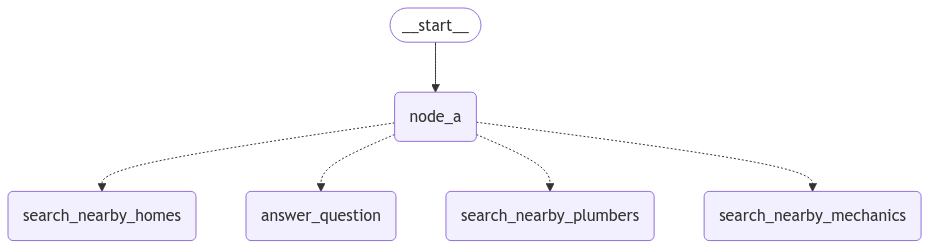

In [14]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
agent_response = graph.invoke({"address": "Karachi","mech_1": "Basheer Ahmed"})

print("\n[FINAL RESPONSE]\n", agent_response)

Called A
Called answer_question

[FINAL RESPONSE]
 {'address': 'Karachi', 'messages': [AIMessage(content='System is down - please try later', additional_kwargs={}, response_metadata={}, id='374d0ac9-56eb-4d48-81fe-430e4752634d')]}


## S2: Update State using Command

After node_1 we can update our state as well. So if user is already in our system we can add it's user data in the stage to personalize user experience.

In [66]:
%%capture --no-stderr
%pip install -U  langgraph tavily-python wikipedia langchain_google_genai langchain_community langgraph_sdk

In [67]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

In [68]:
# Define graph state
class State(TypedDict):
    address: str # address where user wants to search homes for.
    nearby_homes: Optional[list[dict]] # list of nearby homes
    messages: Annotated[list, add_messages]
    user_data: Optional[dict] # user data - for registered users we already have this

In [69]:
# Define the nodes (agents)

def node_a(state: State) -> Command[Literal["search_nearby_homes", "answer_question", "search_nearby_plumbers", "search_nearby_mechanics"]]:
    print("Called A")

    # Get User Data From Memory or Data Store
    fetched_user_data = {"name": "Ammen Alam"}

    # THis is where llm decides which node shall I go next
    value = random.choice()

    # This is a replacement for a conditional edge function
    if value == "search_nearby_homes":
        goto = "search_nearby_homes"
    else:
        goto = "answer_question"

    # note how Command allows you to BOTH update the graph state AND route to the next node
    return Command(
        update={"user_data": fetched_user_data},
        # this is a replacement for an edge
        goto=goto,
    )


# Nodes search_nearby_homes and answer_question are unchanged (just like before)
def search_nearby_homes(state: State):
    print("Called search_nearby_homes!")
    print("UserInfo", state["user_data"])
    return {"nearby_homes": [{"home_1": "Zia House"}, {"home_2": "Qasim House"}]}


def answer_question(state: State):
    print("Called answer_question")
    print("UserInfo", state["user_data"])
    user_name = state["user_data"].get("name", "Guest")
    return {"messages": [AIMessage(content=f"Hi, {user_name} Welcome to Homes AI Search Engine")]}

def llm_node(state: State):
    print("Called llm_node")
    return {"messages": [AIMessage(content="This is a message from the LLM node.")]}

In [85]:
def node_a(state: State) -> Command[Literal["search_nearby_homes", "answer_question", "search_nearby_plumbers", "search_nearby_mechanics","llm_node"]]:
    print("Called A")

    # THis is where llm decides which node shall I go next
    value = random.choice(["search_nearby_homes", "answer_question", "search_nearby_plumbers", "search_nearby_mechanics","llm_node"])

    # This is a replacement for a conditional edge function
    # if value == "search_nearby_homes":
    #     goto = "search_nearby_homes"
    # elif value == "search_nearby_plumbers":
    #     goto = "search_nearby_plumbers"
    # elif value == "search_nearby_mechanics":
    #     goto = "search_nearby_mechanics"
    #     goto = "answer_question"
    goto = value
    # note how Command allows you to BOTH update the graph state AND route to the next node
    return Command(
        # update={},
        # this is a replacement for an edge
        goto=goto,
    )
def search_nearby_homes(state: State):
    print("Called search_nearby_homes!")
    return {"nearby_homes": [{"home_1": "Zia House"}, {"home_2": "Qasim House"}]}


def answer_question(state: State):
    print("Called answer_question")
    return {"messages": [AIMessage(content="System is down - please try later")]}

def search_nearby_plumbers(state: State):
    print("Called search_plumbers")
    return {"user_data": {"plumber_info": [{"plumb_1": "Zain Ali"}, {"plumb_2": "Akbar Khan"}]}}

def search_nearby_mechanics(state: State):
    print("Called search_nearby_mechanics")
    return {"user_data": {"mechanic_info": [{"mech_1": "Basheer Ahmed"}, {"mech_2": "Waleed Danish"}]}}

def llm_node(state: State):
    print("Called llm_node")
    return {"messages": [AIMessage(content="This is a message from the LLM node.")]}

In [86]:
builder = StateGraph(State)
builder.add_edge(START, "node_a")
builder.add_node(node_a)
builder.add_node(search_nearby_homes)
builder.add_node(answer_question)
builder.add_node(search_nearby_plumbers)
builder.add_node(search_nearby_mechanics)
builder.add_node(llm_node)
# NOTE: there are no edges between nodes A, B and C!

graph = builder.compile()

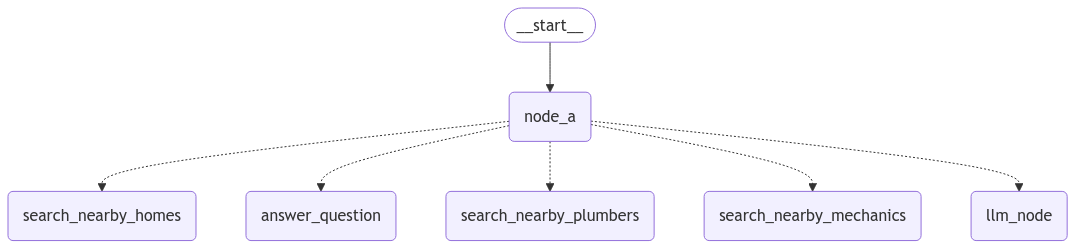

In [88]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [91]:
agent_response = graph.invoke({"user_data":{"Country": "Yemen"}})

print("\n[FINAL RESPONSE]\n", agent_response)

Called A
Called answer_question

[FINAL RESPONSE]
 {'messages': [AIMessage(content='System is down - please try later', additional_kwargs={}, response_metadata={}, id='6c2713f0-c8bc-44b6-b3f9-52ceeb637dde')], 'user_data': {'Country': 'Yemen'}}


# S3: Run Nodes(Agents) in Parallel


Now our user requirement is to both find homes and have conversation with user.
For this:

- We shall call Both Nodes in Parrallel

In [77]:
%%capture --no-stderr
%pip install -U  langgraph tavily-python wikipedia langchain_google_genai langchain_community langgraph_sdk

In [78]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

In [92]:
# Define graph state
class State(TypedDict):
    address: str # address where user wants to search homes for.
    nearby_homes: Optional[list[dict]] # list of nearby homes
    messages: Annotated[list, add_messages]
    user_data: Optional[dict] # user data - for registered users we already have this

In [93]:
# Define the nodes (agents)

def node_a(state: State) -> Command[Literal["search_nearby_homes", "answer_question","llm_node"]]:
    print("Called A")

    # Get User Data From Memory or Data Store
    fetched_user_data = {"name": "Ammen Alam"}

    # note how Command allows you to BOTH update the graph state AND route to the next node
    return Command(
        update={"user_data": fetched_user_data},
        # this is a replacement for an edge
        goto=["search_nearby_homes", "answer_question","llm_node"],
    )


# Nodes search_nearby_homes and answer_question are unchanged (just like before)
def search_nearby_homes(state: State):
    print("Called search_nearby_homes!")
    print("UserInfo", state["user_data"])
    return {"nearby_homes": [{"home_1": "Zia House"}, {"home_2": "Qasim House"}]}


def answer_question(state: State):
    print("Called answer_question")
    print("UserInfo", state["user_data"])
    user_name = state["user_data"].get("name", "Guest")
    return {"messages": [AIMessage(content=f"Hi, {user_name} Welcome to Homes AI Search Engine")]}

def llm_node(state: State):
    print("Called llm_node")
    return {"messages": [AIMessage(content="This is a message from the LLM node.")]}

In [94]:
builder = StateGraph(State)
builder.add_edge(START, "node_a")
builder.add_node(node_a)
builder.add_node(search_nearby_homes)
builder.add_node(answer_question)
builder.add_node(llm_node)
# NOTE: there are no edges between nodes A, B and C!

graph = builder.compile()

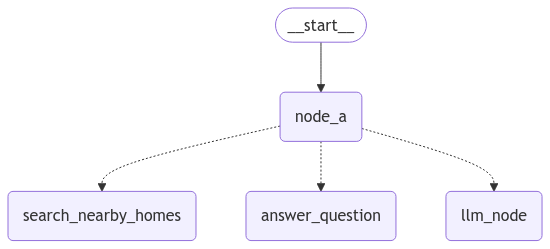

In [95]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [100]:
agent_response = graph.invoke({"address":"Karachi"})
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(agent_response, thread, stream_mode="values"):
    if 'messages' in event and event['messages']:
        event['messages'][-1].pretty_print()

print("\n[FINAL RESPONSE]\n", agent_response)

Called A
Called search_nearby_homes!
Called answer_questionUserInfo {'name': 'Ammen Alam'}
Called llm_node
UserInfo {'name': 'Ammen Alam'}

================================== Ai Message ==================================

This is a message from the LLM node.
Called A
================================== Ai Message ==================================

This is a message from the LLM node.
Called search_nearby_homes!
UserInfo {'name': 'Ammen Alam'}
Called answer_question
UserInfo {'name': 'Ammen Alam'}
Called llm_node
================================== Ai Message ==================================

This is a message from the LLM node.

[FINAL RESPONSE]
 {'address': 'Karachi', 'nearby_homes': [{'home_1': 'Zia House'}, {'home_2': 'Qasim House'}], 'messages': [AIMessage(content='Hi, Ammen Alam Welcome to Homes AI Search Engine', additional_kwargs={}, response_metadata={}, id='1c2584e1-98b9-4503-90de-12ea556ed1ae'), AIMessage(content='This is a message from the LLM node.', additional_kwargs={}, 

In [108]:
agent_response = graph.invoke({"address":"Yemen"})
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(agent_response, thread, stream_mode="values"):
    if 'messages' in event and event['messages']:
        event['messages'][-1].pretty_print()

print("\n[FINAL RESPONSE]\n", agent_response)

Called A
Called search_nearby_homes!
Called answer_question
UserInfo {'name': 'Ammen Alam'}
Called llm_node
UserInfo {'name': 'Ammen Alam'}
================================== Ai Message ==================================

This is a message from the LLM node.
Called A
================================== Ai Message ==================================

This is a message from the LLM node.
Called search_nearby_homes!
UserInfo {'name': 'Ammen Alam'}
Called answer_question
UserInfo {'name': 'Ammen Alam'}
Called llm_node
================================== Ai Message ==================================

This is a message from the LLM node.

[FINAL RESPONSE]
 {'address': 'Yemen', 'nearby_homes': [{'home_1': 'Zia House'}, {'home_2': 'Qasim House'}], 'messages': [AIMessage(content='Hi, Ammen Alam Welcome to Homes AI Search Engine', additional_kwargs={}, response_metadata={}, id='c3dc2628-e74b-4979-9b7f-8f77cc30b082'), AIMessage(content='This is a message from the LLM node.', additional_kwargs={}, re

##

## Final Notes


- **Task**: In `node_a` replace that random with an llm and it will decide in which node to go next.

- **Question:** What will happen if two nodes running in parallel try update same key in state (Think about reducers and find your answer in Module 4)

References:
- https://langchain-ai.github.io/langgraph/how-tos/command/#define-graph
- https://blog.langchain.dev/command-a-new-tool-for-multi-agent-architectures-in-langgraph/